In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('pendulumData-2.csv')

In [3]:
df.head()

,label,g (m/s2),stat uncert,sys uncert,total uncert
0,20.Sep.X.B01.01,9.830,0.0075,"""+0.35,-0.44""",NaN
1,20.Sep.X.B01.02,9.060,0.14,0.23,NaN
2,20.Sep.X.B01.03,9.790,0.02,0.02,NaN
3,20.Sep.X.B01.04,9.882,0.016,0.13,NaN
4,20.Sep.X.B01.05,978.000,17,8,NaN


In [5]:
df = df[df['g (m/s2)'] >= 1]
df = df[df['g (m/s2)'] <= 100]

In [6]:
samples = df['g (m/s2)'].values
freqs_ex, bins_ex = np.histogram(samples, bins=np.arange(min(samples), max(samples), 0.1))

In [9]:
bin_centers_ex = 0.5*(bins_ex[1:]+bins_ex[:-1]) # Adding the left edge and right edge together and then dividing by 2

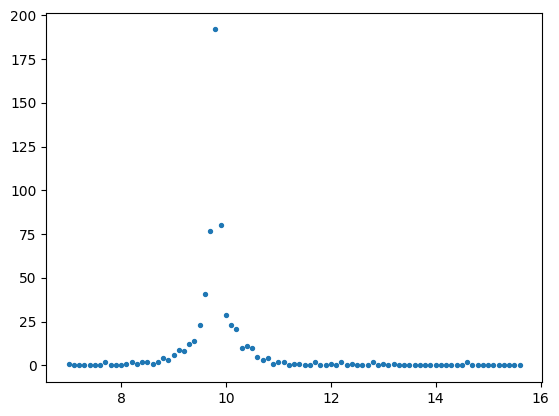

In [12]:
plt.scatter(bin_centers_ex,freqs_ex, s=8)

In [18]:
# Take out zero bins. The discussion for why I do this is beyond the scope of this intro, ask the instructors
# It's not important to know what's going on in this function if you don't want to know.
# If you do want to know, you'll have to think about it
def delete_zeros(bins,counts,err):
    '''
    Inputs:
    bins = the frequency bin centers
    counts = the frequency data
    err = the error data
    Output:
    new_bins = bin centers, but if the frequency of a bin center is zero the bin is removed
    new_counts = frequency data, but if "                    "
    new_err = error data, but if "                       "
    '''
    zeros = np.where(counts==0) # Find the indices where the frequency data is zero
    mask = np.ones(len(counts),dtype=bool) # create a mask of True values
    mask[zeros[0]] = False # Turn the zero parts of the mask False
    new_counts = counts[mask] # Recreate the bin data without the False parts
    new_bins = bins[mask] # Recreate the frequency data without the False parts
    new_err = err[mask] # Recrete the "      "
    return new_bins, new_counts, new_err

In [89]:
def gaussian(x, mu, sigma):
    amp = len(samples) * 0.1 #0.1 is the bin width
    return amp * 1/(sigma*np.sqrt(2*np.pi))*np.exp(-0.5*((x-mu)/sigma)**2)

def two_gaussian(x, mu1, sigma1, mu2, sigma2, amp1, amp2):
    return amp1 * (1/(sigma1*np.sqrt(2*np.pi))*np.exp(-0.5*((x-mu1)/sigma1)**2) + amp2 * 1/(sigma2*np.sqrt(2*np.pi))*np.exp(-0.5*((x-mu2)/sigma2)**2))

def two_gaussian_same_amp(x, mu1, sigma1, mu2, sigma2, amp):
    return amp * (1/(sigma1*np.sqrt(2*np.pi))*np.exp(-0.5*((x-mu1)/sigma1)**2) + amp * 1/(sigma2*np.sqrt(2*np.pi))*np.exp(-0.5*((x-mu2)/sigma2)**2))

In [95]:
import scipy.optimize as opt
bin_centers, freqs, sig = delete_zeros(bin_centers_ex, freqs_ex, np.sqrt(freqs_ex)) # Take out the zeros from our data
popt, pcov = opt.curve_fit(f=two_gaussian,
                           xdata=bin_centers,
                           ydata=freqs,
                           sigma=sig,
                           p0=[10,1,10,1,60,60], # Initial guess for params
                           absolute_sigma=True,
                           maxfev = 20000) # Fit function

uncert = np.sqrt(np.diag(pcov))

In [96]:
print(popt)
print(uncert)

[ 9.80373702  0.46247344  9.80052893 -0.06873883 29.9880608  -0.93202334]
[0.02704337 0.02521608 0.00522814 0.00463417 2.18011055 0.1154572 ]


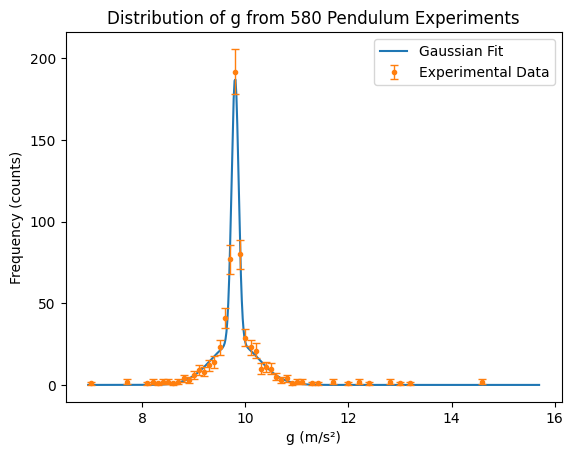

In [97]:
x = np.linspace(start=min(samples),stop=max(samples),num=500,endpoint=True) # Define x for smoother plotting of our poisson fit function

plt.plot(x, two_gaussian(x, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5]),
          label='Gaussian Fit') # Plot fit function
# If you have a bunch of arguments in popt, you're better off using *popt instead of listing out each popt variabe:
# If you don't know what the * does, quickly google it.
# plt.plot(x, poisson(x,*popt))

plt.errorbar(bin_centers, freqs, yerr=sig, linewidth=1, ls='none', fmt='o', capsize=3, ms=3, label = 'Experimental Data') # Plot actual data
plt.title('Distribution of g from 580 Pendulum Experiments')
plt.xlabel('g (m/s²)')
plt.ylabel('Frequency (counts)')
plt.legend()

In [70]:
def chisq(func,popt,x,y,sig):
    '''
    Inputs:
    func = function to generate expected value
    x = x data
    y = y data
    sig = sigma data
    Outputs:
    chi2 = chi-squared value
    '''
    expected_vals = func(x, *popt) # Again, better off using *popt
    return np.sum((y-expected_vals)**2/sig**2)

chi2 = chisq(two_gaussian,popt,bin_centers,freqs,sig)
chi2

38.91422630850765

In [75]:
dof = len(bin_centers) - len(popt) # Our degrees of freedom is equal to the number of data points minus the number of fit parameters

chi2/dof

1.0517358461758826

In [74]:
from scipy import stats

chi2_probs = 1 - stats.chi2.cdf(chi2,dof) # Get the probability by subtracting 1 from the cumulative distribution function

chi2_probs

0.38358893746593736

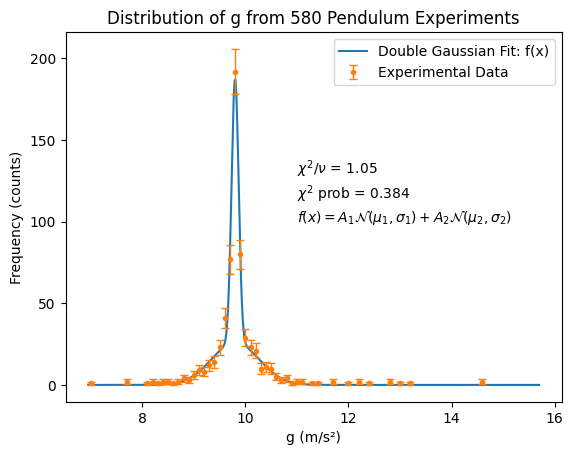

In [ ]:
x = np.linspace(start=min(samples),stop=max(samples),num=500,endpoint=True) # Define x for smoother plotting of our poisson fit function

plt.plot(x, two_gaussian(x, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5]),
          label='Double Gaussian Fit: f(x)') # Plot fit function
# If you have a bunch of arguments in popt, you're better off using *popt instead of listing out each popt variabe:
# If you don't know what the * does, quickly google it.
# plt.plot(x, poisson(x,*popt))

plt.text(11,100, f'$\chi^2/\\nu$ = {chi2/dof:.2f}\n$\chi^2$ prob = {chi2_probs:.3f} \n$f(x) = A_1\mathcal{{N}}(\mu_1, \sigma_1) + A_2\mathcal{{N}}(\mu_2, \sigma_2)$ \n A_1 = {popt[4]:.2f}, \n $\mu_1 = {popt[0]:.2f}, \mu_2 = {popt[2]:.2f}$', fontsize=10)

plt.errorbar(bin_centers, freqs, yerr=sig, linewidth=1, ls='none', fmt='o', capsize=3, ms=3, label = 'Experimental Data') # Plot actual data
plt.title('Distribution of g from 580 Pendulum Experiments')
plt.xlabel('g (m/s²)')
plt.ylabel('Frequency (counts)')
plt.legend()
plt.show()